# 01 - Data preparation and opinion network construction

Builds a respondent (agent) agreement network and an attitude (item) projection from the class survey, following MacCarron et al. (2020) and Dinkelberg et al. (2021).

Run from `code/` or the repo root. Writes GraphML and tables under `artifacts/` for analysis and Cytoscape import.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
if not (ROOT / "Survey_Results_UC.csv").exists() and (ROOT.parent / "Survey_Results_UC.csv").exists():
    ROOT = ROOT.parent
elif not (ROOT / "Survey_Results_UC.csv").exists() and (ROOT / ".." / "Survey_Results_UC.csv").exists():
    ROOT = (ROOT / "..").resolve()
DATA_PATH = ROOT / 'Survey_Results_UC.csv'
ART = ROOT / 'artifacts'
FIG = ROOT / 'figures'
ART.mkdir(exist_ok=True)
FIG.mkdir(exist_ok=True)

LIKERT_MAP = {
    'Strongly Disagree': -1.0,
    'Disagree': -0.5,
    'Neutral': 0.0,
    'Agree': 0.5,
    'Strongly Agree': 1.0,
}
MISSING_LABELS = {'', 'No Comments', 'N/A', 'NA'}
MIN_COMPLETENESS = 0.50  # keep respondents answering at least half the items
MIN_OVERLAP = 20         # min jointly answered items for a pair similarity
GIANT_FRAC = 0.80        # Dinkelberg-style giant-component target

sns.set_theme(style='whitegrid', context='notebook')
print('ROOT', ROOT)
print('data exists', DATA_PATH.exists())


ROOT /home/vishak/IIITH-IV-I/dpcn/dpcn-a1-opinion-network-team34
data exists True


## Load and encode survey

In [2]:
raw = pd.read_csv(DATA_PATH, encoding='utf-8-sig')
id_col = raw.columns[0]
item_cols = list(raw.columns[1:])

def encode_cell(v):
    if pd.isna(v):
        return np.nan
    s = str(v).strip()
    if s in MISSING_LABELS:
        return np.nan
    if s not in LIKERT_MAP:
        raise ValueError(f'Unexpected Likert label: {s!r}')
    return LIKERT_MAP[s]

encoded = raw[item_cols].apply(lambda col: col.map(encode_cell))
encoded.insert(0, 'respondent_id', raw[id_col].astype(str))

n_items = len(item_cols)
completeness = encoded[item_cols].notna().sum(axis=1) / n_items
encoded['completeness'] = completeness

kept = encoded[encoded['completeness'] >= MIN_COMPLETENESS].copy().reset_index(drop=True)
dropped = encoded[encoded['completeness'] < MIN_COMPLETENESS]

print(f'respondents total={len(encoded)}, kept={len(kept)}, dropped={len(dropped)}')
print(f'items={n_items}, min completeness={MIN_COMPLETENESS}')
print('dropped ids:', dropped['respondent_id'].tolist())

themes = {'T': [], 'E': [], 'S': [], 'V': []}
for c in item_cols:
    themes[c[0]].append(c)
for t, cols in themes.items():
    print(f'theme {t}: {len(cols)} items')

missing_counts = encoded[item_cols].isna().sum()
print('missing cells total', int(missing_counts.sum()))
print('missing by theme:')
for t, cols in themes.items():
    print(f'  {t}: {int(encoded[cols].isna().sum().sum())}')

respondents total=96, kept=87, dropped=9
items=60, min completeness=0.5
dropped ids: ['30', '39', '44', '60', '68', '73', '77', '78', '87']
theme T: 15 items
theme E: 15 items
theme S: 15 items
theme V: 15 items
missing cells total 542
missing by theme:
  T: 86
  E: 143
  S: 148
  V: 165


-1.0     111
-0.5     253
 0.0     667
 0.5    1889
 1.0    2238
Name: count, dtype: int64
mean opinion (kept): 0.5709577355564173


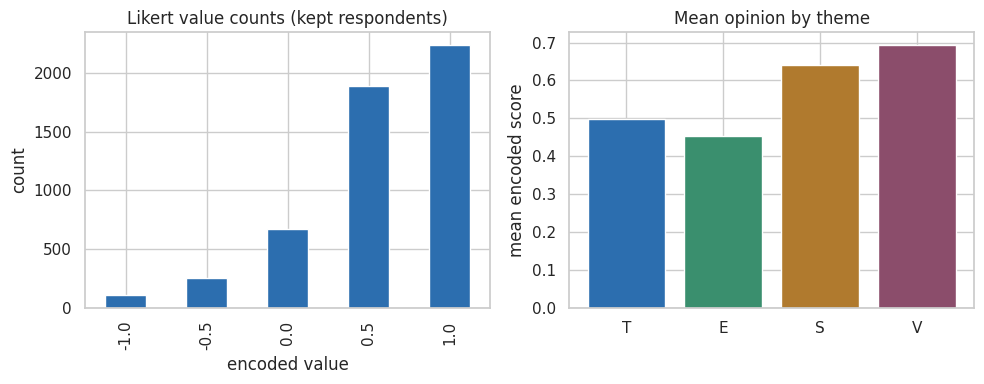

379

In [3]:
# EDA: response distribution and Agree skew
flat = kept[item_cols].stack().dropna()
vc = flat.value_counts().sort_index()
print(vc)
print('mean opinion (kept):', float(flat.mean()))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
vc.plot(kind='bar', ax=axes[0], color='#2c6eaf')
axes[0].set_title('Likert value counts (kept respondents)')
axes[0].set_xlabel('encoded value')
axes[0].set_ylabel('count')

theme_means = {t: kept[cols].stack().dropna().mean() for t, cols in themes.items()}
axes[1].bar(list(theme_means.keys()), list(theme_means.values()), color=['#2c6eaf', '#3a8f6e', '#b07a2e', '#8b4d6b'])
axes[1].set_title('Mean opinion by theme')
axes[1].set_ylabel('mean encoded score')
axes[1].axhline(0, color='gray', lw=0.8)
fig.tight_layout()
fig.savefig(FIG / 'eda_likert_and_themes.png', dpi=200, bbox_inches='tight')
plt.show()

kept.to_csv(ART / 'encoded_respondents.csv', index=False)
meta = {
    'n_raw': len(encoded),
    'n_kept': len(kept),
    'n_items': n_items,
    'min_completeness': MIN_COMPLETENESS,
    'min_overlap': MIN_OVERLAP,
    'giant_frac_target': GIANT_FRAC,
    'likert_map': LIKERT_MAP,
    'dropped_ids': dropped['respondent_id'].tolist(),
}
(ART / 'prep_meta.json').write_text(json.dumps(meta, indent=2))

## Manhattan agreement similarity (MacCarron / Dinkelberg)

For jointly answered items, $S_{ij} = n_{ij} - \sum |q_{if}-q_{jf}|$, ranging from $-n_{ij}$ to $+n_{ij}$. Full agreement gives $S_{ij}=n_{ij}$.

valid pairs 3741
S stats (upper triangle):
count    3741.000000
mean       33.711441
std         7.454725
min        -3.000000
25%        30.000000
50%        34.500000
75%        38.500000
max        52.000000
dtype: float64


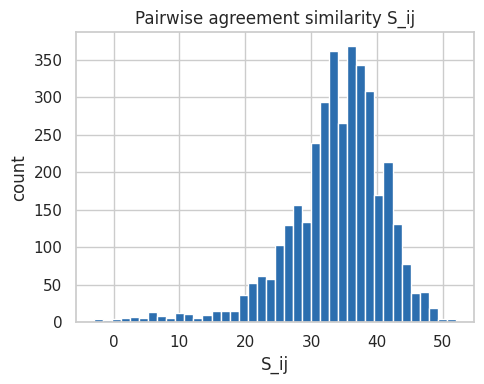

In [4]:
X = kept[item_cols].to_numpy(dtype=float)
ids = kept['respondent_id'].tolist()
n = len(ids)

S = np.full((n, n), np.nan)
overlap = np.zeros((n, n), dtype=int)

for i in range(n):
    S[i, i] = np.nan  # no self-loops later
    for j in range(i + 1, n):
        mask = np.isfinite(X[i]) & np.isfinite(X[j])
        n_ij = int(mask.sum())
        overlap[i, j] = overlap[j, i] = n_ij
        if n_ij < MIN_OVERLAP:
            continue
        diff = np.abs(X[i, mask] - X[j, mask]).sum()
        s_ij = n_ij - diff
        S[i, j] = S[j, i] = s_ij

valid_pairs = np.isfinite(S)
print('valid pairs', int(valid_pairs.sum() // 2))
print('S stats (upper triangle):')
vals = S[np.triu_indices(n, k=1)]
vals = vals[np.isfinite(vals)]
print(pd.Series(vals).describe())

np.save(ART / 'similarity_matrix.npy', S)
np.save(ART / 'overlap_matrix.npy', overlap)
pd.DataFrame(S, index=ids, columns=ids).to_csv(ART / 'similarity_matrix.csv')

fig, ax = plt.subplots(figsize=(5, 4))
ax.hist(vals, bins=40, color='#2c6eaf', edgecolor='white')
ax.set_title('Pairwise agreement similarity S_ij')
ax.set_xlabel('S_ij')
ax.set_ylabel('count')
fig.tight_layout()
fig.savefig(FIG / 'similarity_distribution.png', dpi=200, bbox_inches='tight')
plt.show()

## Threshold search for giant component (~80%)

/tmp/ipykernel_35481/2103201401.py:7: RuntimeWarning: Mean of empty slice
  theme_means_node[f'mean_{t}'] = float(np.nanmean(row[cols].to_numpy(dtype=float)))
/tmp/ipykernel_35481/2103201401.py:7: RuntimeWarning: Mean of empty slice
  theme_means_node[f'mean_{t}'] = float(np.nanmean(row[cols].to_numpy(dtype=float)))
/tmp/ipykernel_35481/2103201401.py:7: RuntimeWarning: Mean of empty slice
  theme_means_node[f'mean_{t}'] = float(np.nanmean(row[cols].to_numpy(dtype=float)))
/tmp/ipykernel_35481/2103201401.py:7: RuntimeWarning: Mean of empty slice
  theme_means_node[f'mean_{t}'] = float(np.nanmean(row[cols].to_numpy(dtype=float)))
/tmp/ipykernel_35481/2103201401.py:7: RuntimeWarning: Mean of empty slice
  theme_means_node[f'mean_{t}'] = float(np.nanmean(row[cols].to_numpy(dtype=float)))
/tmp/ipykernel_35481/2103201401.py:7: RuntimeWarning: Mean of empty slice
  theme_means_node[f'mean_{t}'] = float(np.nanmean(row[cols].to_numpy(dtype=float)))


/tmp/ipykernel_35481/2103201401.py:7: RuntimeWarning: Mean of empty slice
  theme_means_node[f'mean_{t}'] = float(np.nanmean(row[cols].to_numpy(dtype=float)))
/tmp/ipykernel_35481/2103201401.py:7: RuntimeWarning: Mean of empty slice
  theme_means_node[f'mean_{t}'] = float(np.nanmean(row[cols].to_numpy(dtype=float)))
/tmp/ipykernel_35481/2103201401.py:7: RuntimeWarning: Mean of empty slice
  theme_means_node[f'mean_{t}'] = float(np.nanmean(row[cols].to_numpy(dtype=float)))
/tmp/ipykernel_35481/2103201401.py:7: RuntimeWarning: Mean of empty slice
  theme_means_node[f'mean_{t}'] = float(np.nanmean(row[cols].to_numpy(dtype=float)))


/tmp/ipykernel_35481/2103201401.py:7: RuntimeWarning: Mean of empty slice
  theme_means_node[f'mean_{t}'] = float(np.nanmean(row[cols].to_numpy(dtype=float)))
/tmp/ipykernel_35481/2103201401.py:7: RuntimeWarning: Mean of empty slice
  theme_means_node[f'mean_{t}'] = float(np.nanmean(row[cols].to_numpy(dtype=float)))
/tmp/ipykernel_35481/2103201401.py:7: RuntimeWarning: Mean of empty slice
  theme_means_node[f'mean_{t}'] = float(np.nanmean(row[cols].to_numpy(dtype=float)))
/tmp/ipykernel_35481/2103201401.py:7: RuntimeWarning: Mean of empty slice
  theme_means_node[f'mean_{t}'] = float(np.nanmean(row[cols].to_numpy(dtype=float)))
/tmp/ipykernel_35481/2103201401.py:7: RuntimeWarning: Mean of empty slice
  theme_means_node[f'mean_{t}'] = float(np.nanmean(row[cols].to_numpy(dtype=float)))


/tmp/ipykernel_35481/2103201401.py:7: RuntimeWarning: Mean of empty slice
  theme_means_node[f'mean_{t}'] = float(np.nanmean(row[cols].to_numpy(dtype=float)))
/tmp/ipykernel_35481/2103201401.py:7: RuntimeWarning: Mean of empty slice
  theme_means_node[f'mean_{t}'] = float(np.nanmean(row[cols].to_numpy(dtype=float)))
/tmp/ipykernel_35481/2103201401.py:7: RuntimeWarning: Mean of empty slice
  theme_means_node[f'mean_{t}'] = float(np.nanmean(row[cols].to_numpy(dtype=float)))
/tmp/ipykernel_35481/2103201401.py:7: RuntimeWarning: Mean of empty slice
  theme_means_node[f'mean_{t}'] = float(np.nanmean(row[cols].to_numpy(dtype=float)))


/tmp/ipykernel_35481/2103201401.py:7: RuntimeWarning: Mean of empty slice
  theme_means_node[f'mean_{t}'] = float(np.nanmean(row[cols].to_numpy(dtype=float)))
/tmp/ipykernel_35481/2103201401.py:7: RuntimeWarning: Mean of empty slice
  theme_means_node[f'mean_{t}'] = float(np.nanmean(row[cols].to_numpy(dtype=float)))
/tmp/ipykernel_35481/2103201401.py:7: RuntimeWarning: Mean of empty slice
  theme_means_node[f'mean_{t}'] = float(np.nanmean(row[cols].to_numpy(dtype=float)))
/tmp/ipykernel_35481/2103201401.py:7: RuntimeWarning: Mean of empty slice
  theme_means_node[f'mean_{t}'] = float(np.nanmean(row[cols].to_numpy(dtype=float)))
/tmp/ipykernel_35481/2103201401.py:7: RuntimeWarning: Mean of empty slice
  theme_means_node[f'mean_{t}'] = float(np.nanmean(row[cols].to_numpy(dtype=float)))


...

/tmp/ipykernel_35481/2103201401.py:7: RuntimeWarning: Mean of empty slice
  theme_means_node[f'mean_{t}'] = float(np.nanmean(row[cols].to_numpy(dtype=float)))
/tmp/ipykernel_35481/2103201401.py:7: RuntimeWarning: Mean of empty slice
  theme_means_node[f'mean_{t}'] = float(np.nanmean(row[cols].to_numpy(dtype=float)))
/tmp/ipykernel_35481/2103201401.py:7: RuntimeWarning: Mean of empty slice
  theme_means_node[f'mean_{t}'] = float(np.nanmean(row[cols].to_numpy(dtype=float)))
/tmp/ipykernel_35481/2103201401.py:7: RuntimeWarning: Mean of empty slice
  theme_means_node[f'mean_{t}'] = float(np.nanmean(row[cols].to_numpy(dtype=float)))
/tmp/ipykernel_35481/2103201401.py:7: RuntimeWarning: Mean of empty slice
  theme_means_node[f'mean_{t}'] = float(np.nanmean(row[cols].to_numpy(dtype=float)))
/tmp/ipykernel_35481/2103201401.py:7: RuntimeWarning: Mean of empty slice
  theme_means_node[f'mean_{t}'] = float(np.nanmean(row[cols].to_numpy(dtype=float)))


/tmp/ipykernel_35481/2103201401.py:7: RuntimeWarning: Mean of empty slice
  theme_means_node[f'mean_{t}'] = float(np.nanmean(row[cols].to_numpy(dtype=float)))
/tmp/ipykernel_35481/2103201401.py:7: RuntimeWarning: Mean of empty slice
  theme_means_node[f'mean_{t}'] = float(np.nanmean(row[cols].to_numpy(dtype=float)))
/tmp/ipykernel_35481/2103201401.py:7: RuntimeWarning: Mean of empty slice
  theme_means_node[f'mean_{t}'] = float(np.nanmean(row[cols].to_numpy(dtype=float)))
/tmp/ipykernel_35481/2103201401.py:7: RuntimeWarning: Mean of empty slice
  theme_means_node[f'mean_{t}'] = float(np.nanmean(row[cols].to_numpy(dtype=float)))


/tmp/ipykernel_35481/2103201401.py:7: RuntimeWarning: Mean of empty slice
  theme_means_node[f'mean_{t}'] = float(np.nanmean(row[cols].to_numpy(dtype=float)))
/tmp/ipykernel_35481/2103201401.py:7: RuntimeWarning: Mean of empty slice
  theme_means_node[f'mean_{t}'] = float(np.nanmean(row[cols].to_numpy(dtype=float)))
/tmp/ipykernel_35481/2103201401.py:7: RuntimeWarning: Mean of empty slice
  theme_means_node[f'mean_{t}'] = float(np.nanmean(row[cols].to_numpy(dtype=float)))


/tmp/ipykernel_35481/2103201401.py:7: RuntimeWarning: Mean of empty slice
  theme_means_node[f'mean_{t}'] = float(np.nanmean(row[cols].to_numpy(dtype=float)))
/tmp/ipykernel_35481/2103201401.py:7: RuntimeWarning: Mean of empty slice
  theme_means_node[f'mean_{t}'] = float(np.nanmean(row[cols].to_numpy(dtype=float)))
/tmp/ipykernel_35481/2103201401.py:7: RuntimeWarning: Mean of empty slice
  theme_means_node[f'mean_{t}'] = float(np.nanmean(row[cols].to_numpy(dtype=float)))
/tmp/ipykernel_35481/2103201401.py:7: RuntimeWarning: Mean of empty slice
  theme_means_node[f'mean_{t}'] = float(np.nanmean(row[cols].to_numpy(dtype=float)))


chosen theta 41.5
{'theta': 41.5, 'n_nodes': 87.0, 'n_edges': 456.0, 'giant_frac': 0.8045977011494253, 'giant_size': 70.0}
 theta  n_nodes  n_edges  giant_frac  giant_size
  46.5       87       67    0.264368          23
  46.0       87       86    0.287356          25
  45.5       87      105    0.298851          26
  45.0       87      121    0.482759          42
  44.5       87      148    0.505747          44
  44.0       87      182    0.551724          48
  43.5       87      222    0.597701          52
  43.0       87      264    0.620690          54
  42.5       87      313    0.666667          58
  42.0       87      370    0.747126          65
  41.5       87      456    0.804598          70
  41.0       87      527    0.839080          73
  40.5       87      610    0.862069          75
  40.0       87      696    0.873563          76
  39.5       87      787    0.873563          76


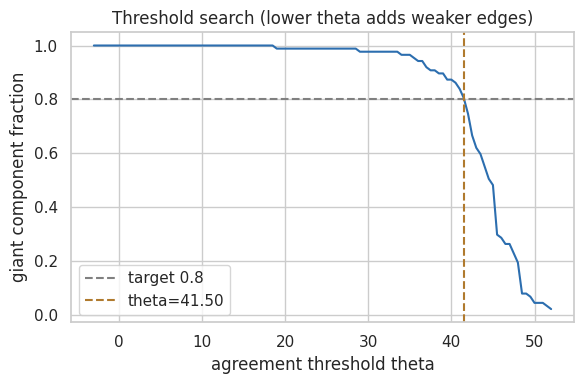

In [5]:
def build_agent_graph(theta, similarity=S, node_ids=ids):
    G = nx.Graph()
    for k, rid in enumerate(node_ids):
        row = kept.iloc[k]
        theme_means_node = {}
        for t, cols in themes.items():
            theme_means_node[f'mean_{t}'] = float(np.nanmean(row[cols].to_numpy(dtype=float)))
        G.add_node(
            rid,
            respondent_id=rid,
            completeness=float(row['completeness']),
            mean_opinion=float(np.nanmean(row[item_cols].to_numpy(dtype=float))),
            **theme_means_node,
        )
    iu, ju = np.triu_indices(len(node_ids), k=1)
    for i, j in zip(iu, ju):
        s = similarity[i, j]
        if np.isfinite(s) and s >= theta:
            G.add_edge(node_ids[i], node_ids[j], weight=float(s), similarity=float(s), overlap=int(overlap[i, j]))
    return G


def giant_fraction(G):
    if G.number_of_nodes() == 0:
        return 0.0, 0
    if G.number_of_edges() == 0:
        return 1.0 / G.number_of_nodes(), 1
    largest = max(nx.connected_components(G), key=len)
    return len(largest) / G.number_of_nodes(), len(largest)


# Scan thresholds from high to low agreement
cand = sorted({float(v) for v in vals}, reverse=True)
records = []
chosen_theta = None
for theta in cand:
    Gtmp = build_agent_graph(theta)
    gf, gsize = giant_fraction(Gtmp)
    records.append({'theta': theta, 'n_nodes': Gtmp.number_of_nodes(), 'n_edges': Gtmp.number_of_edges(), 'giant_frac': gf, 'giant_size': gsize})
    if chosen_theta is None and gf >= GIANT_FRAC and Gtmp.number_of_edges() > 0:
        chosen_theta = theta

thr_df = pd.DataFrame(records)
if chosen_theta is None:
    # fallback: densest threshold that maximizes giant frac
    chosen_theta = float(thr_df.loc[thr_df['giant_frac'].idxmax(), 'theta'])

print('chosen theta', chosen_theta)
print(thr_df[thr_df['theta'] == chosen_theta].iloc[0].to_dict())

# sensitivity nearby
nearby = thr_df[(thr_df['theta'] >= chosen_theta - 5) & (thr_df['theta'] <= chosen_theta + 5)]
display_cols = nearby.drop_duplicates('theta').sort_values('theta', ascending=False).head(15)
print(display_cols.to_string(index=False))

thr_df.to_csv(ART / 'threshold_scan.csv', index=False)
(ART / 'chosen_theta.json').write_text(json.dumps({'theta': chosen_theta, 'giant_frac_target': GIANT_FRAC}, indent=2))

fig, ax = plt.subplots(figsize=(6, 4))
plot_df = thr_df.sort_values('theta')
# downsample for readability
plot_df = plot_df.iloc[::max(1, len(plot_df)//200)]
ax.plot(plot_df['theta'], plot_df['giant_frac'], color='#2c6eaf')
ax.axhline(GIANT_FRAC, color='gray', ls='--', label=f'target {GIANT_FRAC}')
ax.axvline(chosen_theta, color='#b07a2e', ls='--', label=f'theta={chosen_theta:.2f}')
ax.set_xlabel('agreement threshold theta')
ax.set_ylabel('giant component fraction')
ax.set_title('Threshold search (lower theta adds weaker edges)')
ax.legend()
fig.tight_layout()
fig.savefig(FIG / 'threshold_giant_component.png', dpi=200, bbox_inches='tight')
plt.show()

## Build and export agent network

In [6]:
G_agent = build_agent_graph(chosen_theta)
print(G_agent)
gf, gsize = giant_fraction(G_agent)
print(f'giant frac={gf:.3f}, giant size={gsize}, density={nx.density(G_agent):.4f}')

nx.write_graphml(G_agent, ART / 'agent_network.graphml')
nx.write_edgelist(G_agent, ART / 'agent_edges.csv', delimiter=',', data=['weight', 'overlap'])

nodes_df = pd.DataFrame([
    {
        'respondent_id': n,
        **{k: v for k, v in G_agent.nodes[n].items()}
    }
    for n in G_agent.nodes
])
nodes_df.to_csv(ART / 'agent_nodes.csv', index=False)

edges_df = pd.DataFrame([
    {'source': u, 'target': v, **d}
    for u, v, d in G_agent.edges(data=True)
])
edges_df.to_csv(ART / 'agent_edge_table.csv', index=False)
print('wrote agent GraphML and tables')

# theme-restricted networks (optional slices)
theme_graphs = {}
for t, cols in themes.items():
    Xt = kept[cols].to_numpy(dtype=float)
    St = np.full((n, n), np.nan)
    min_ov_t = max(5, len(cols) // 2)
    for i in range(n):
        for j in range(i + 1, n):
            mask = np.isfinite(Xt[i]) & np.isfinite(Xt[j])
            n_ij = int(mask.sum())
            if n_ij < min_ov_t:
                continue
            St[i, j] = St[j, i] = n_ij - np.abs(Xt[i, mask] - Xt[j, mask]).sum()
    vals_t = St[np.triu_indices(n, k=1)]
    vals_t = vals_t[np.isfinite(vals_t)]
    # choose theta for ~80% giant within theme
    theta_t = None
    for th in sorted(set(vals_t), reverse=True):
        Gt = nx.Graph()
        Gt.add_nodes_from(ids)
        iu, ju = np.triu_indices(n, k=1)
        for i, j in zip(iu, ju):
            s = St[i, j]
            if np.isfinite(s) and s >= th:
                Gt.add_edge(ids[i], ids[j], weight=float(s))
        gf_t, _ = giant_fraction(Gt)
        if gf_t >= GIANT_FRAC and Gt.number_of_edges() > 0:
            theta_t = th
            theme_graphs[t] = Gt
            break
    if theta_t is None and len(vals_t):
        theta_t = float(np.median(vals_t))
        Gt = nx.Graph()
        Gt.add_nodes_from(ids)
        iu, ju = np.triu_indices(n, k=1)
        for i, j in zip(iu, ju):
            s = St[i, j]
            if np.isfinite(s) and s >= theta_t:
                Gt.add_edge(ids[i], ids[j], weight=float(s))
        theme_graphs[t] = Gt
    nx.write_graphml(theme_graphs[t], ART / f'agent_network_theme_{t}.graphml')
    print(f'theme {t}: theta={theta_t}, {theme_graphs[t]}')

/tmp/ipykernel_35481/2103201401.py:7: RuntimeWarning: Mean of empty slice
  theme_means_node[f'mean_{t}'] = float(np.nanmean(row[cols].to_numpy(dtype=float)))


Graph with 87 nodes and 456 edges
giant frac=0.805, giant size=70, density=0.1219
wrote agent GraphML and tables
theme T: theta=10.5, Graph with 87 nodes and 372 edges
theme E: theta=11.0, Graph with 87 nodes and 353 edges
theme S: theta=11.0, Graph with 87 nodes and 812 edges


theme V: theta=12.0, Graph with 87 nodes and 692 edges


## Attitude projection (item-item co-endorsement)

Edge weight $W_{ab} = \sum_i q_{ia} q_{ib}$ over respondents answering both items (product of [-1,1] scores). Positive weight means co-endorsement of the same polarity.

In [7]:
short_labels = {c: c.split('.')[0].strip() for c in item_cols}
Y = kept[item_cols].to_numpy(dtype=float)
m = len(item_cols)
W = np.zeros((m, m))
counts = np.zeros((m, m), dtype=int)

for a in range(m):
    for b in range(a + 1, m):
        mask = np.isfinite(Y[:, a]) & np.isfinite(Y[:, b])
        counts[a, b] = counts[b, a] = int(mask.sum())
        if mask.sum() == 0:
            continue
        w = float(np.sum(Y[mask, a] * Y[mask, b]))
        W[a, b] = W[b, a] = w

# keep positive co-endorsement edges above a percentile to sparsify for viz
pos_vals = W[np.triu_indices(m, k=1)]
pos_vals = pos_vals[pos_vals > 0]
att_thresh = float(np.quantile(pos_vals, 0.70)) if len(pos_vals) else 0.0
print('attitude positive-edge threshold (70th pct of positive W)', att_thresh)

G_att = nx.Graph()
for idx, c in enumerate(item_cols):
    G_att.add_node(
        short_labels[c],
        full_label=c,
        theme=c[0],
        mean_score=float(np.nanmean(Y[:, idx])),
        variance=float(np.nanvar(Y[:, idx])),
    )

for a in range(m):
    for b in range(a + 1, m):
        w = W[a, b]
        if w >= att_thresh:
            G_att.add_edge(
                short_labels[item_cols[a]],
                short_labels[item_cols[b]],
                weight=float(w),
                n_respondents=int(counts[a, b]),
            )

print(G_att)
nx.write_graphml(G_att, ART / 'attitude_network.graphml')
pd.DataFrame(
    [{'source': u, 'target': v, **d} for u, v, d in G_att.edges(data=True)]
).to_csv(ART / 'attitude_edges.csv', index=False)
pd.DataFrame(
    [{'item': n, **d} for n, d in G_att.nodes(data=True)]
).to_csv(ART / 'attitude_nodes.csv', index=False)

# contested items: highest variance
item_stats = pd.DataFrame({
    'item': [short_labels[c] for c in item_cols],
    'full_label': item_cols,
    'theme': [c[0] for c in item_cols],
    'mean': [float(np.nanmean(Y[:, i])) for i in range(m)],
    'variance': [float(np.nanvar(Y[:, i])) for i in range(m)],
}).sort_values('variance', ascending=False)
item_stats.to_csv(ART / 'item_stats.csv', index=False)
print('most contested items:')
print(item_stats.head(10).to_string(index=False))

summary = {
    'chosen_theta': chosen_theta,
    'agent_nodes': G_agent.number_of_nodes(),
    'agent_edges': G_agent.number_of_edges(),
    'agent_giant_frac': gf,
    'attitude_nodes': G_att.number_of_nodes(),
    'attitude_edges': G_att.number_of_edges(),
    'attitude_thresh': att_thresh,
}
(ART / 'network_summary.json').write_text(json.dumps(summary, indent=2))
print('done notebook 01')
print(json.dumps(summary, indent=2))

attitude positive-edge threshold (70th pct of positive W) 40.75
Graph with 60 nodes and 498 edges
most contested items:
item                                                                                  full_label theme      mean  variance
 E04            E04. High-quality online learning can effectively complement classroom teaching.     E  0.218391  0.337363
 E03                                 E03. Class attendance should be compulsory for all courses.     E -0.471264  0.312393
 E02             E02. Traditional written examinations accurately measure a student's knowledge.     E -0.080460  0.309618
 T08                             T08. AI-assisted diagnosis should become routine in healthcare.     T  0.034884  0.301109
 S02 S02. Universities should encourage students to participate in community service activities.     S  0.419540  0.275135
 T07               T07. Robots should replace humans in hazardous occupations whenever possible.     T  0.603448  0.270908
 E09           E09.